# 01 - EDA & Hiểu dữ liệu: Pima Indians Diabetes Database

**Mục tiêu notebook này:**
- Load và xem tổng quan dataset
- Kiểm tra missing values (ẩn dưới dạng 0)
- Phân tích phân bố từng biến
- Phân tích mối quan hệ với Outcome (target)
- Phát hiện outlier
- Correlation & heatmap
- Kết luận insights để preprocessing

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Load dữ liệu

In [3]:
DATA_PATH = "../data/raw/diabetes.csv" 

df = pd.read_csv(DATA_PATH)
print("Kích thước dataset:", df.shape)
df.head()

Kích thước dataset: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
# Thông tin cơ bản
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


## 2. Thống kê mô tả

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


**Quan sát ban đầu:**
- Glucose, BloodPressure, SkinThickness, Insulin, BMI có giá trị min = 0 → rất có thể là **missing values ẩn** (không hợp lý về mặt y khoa).
- Outcome: 0/1 → bài toán phân loại nhị phân (imbalance nhẹ).

## 3. Kiểm tra missing values (ẩn dưới dạng 0)

In [6]:
cols_with_zero = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

print("Số lượng giá trị 0 ở các cột nghi ngờ missing:")
for col in cols_with_zero:
    zeros = (df[col] == 0).sum()
    print(f"{col}: {zeros} giá trị 0 ({zeros/len(df)*100:.2f}%)")

Số lượng giá trị 0 ở các cột nghi ngờ missing:
Glucose: 5 giá trị 0 (0.65%)
BloodPressure: 35 giá trị 0 (4.56%)
SkinThickness: 227 giá trị 0 (29.56%)
Insulin: 374 giá trị 0 (48.70%)
BMI: 11 giá trị 0 (1.43%)


## 4. Phân bố từng biến (Histogram + Boxplot)

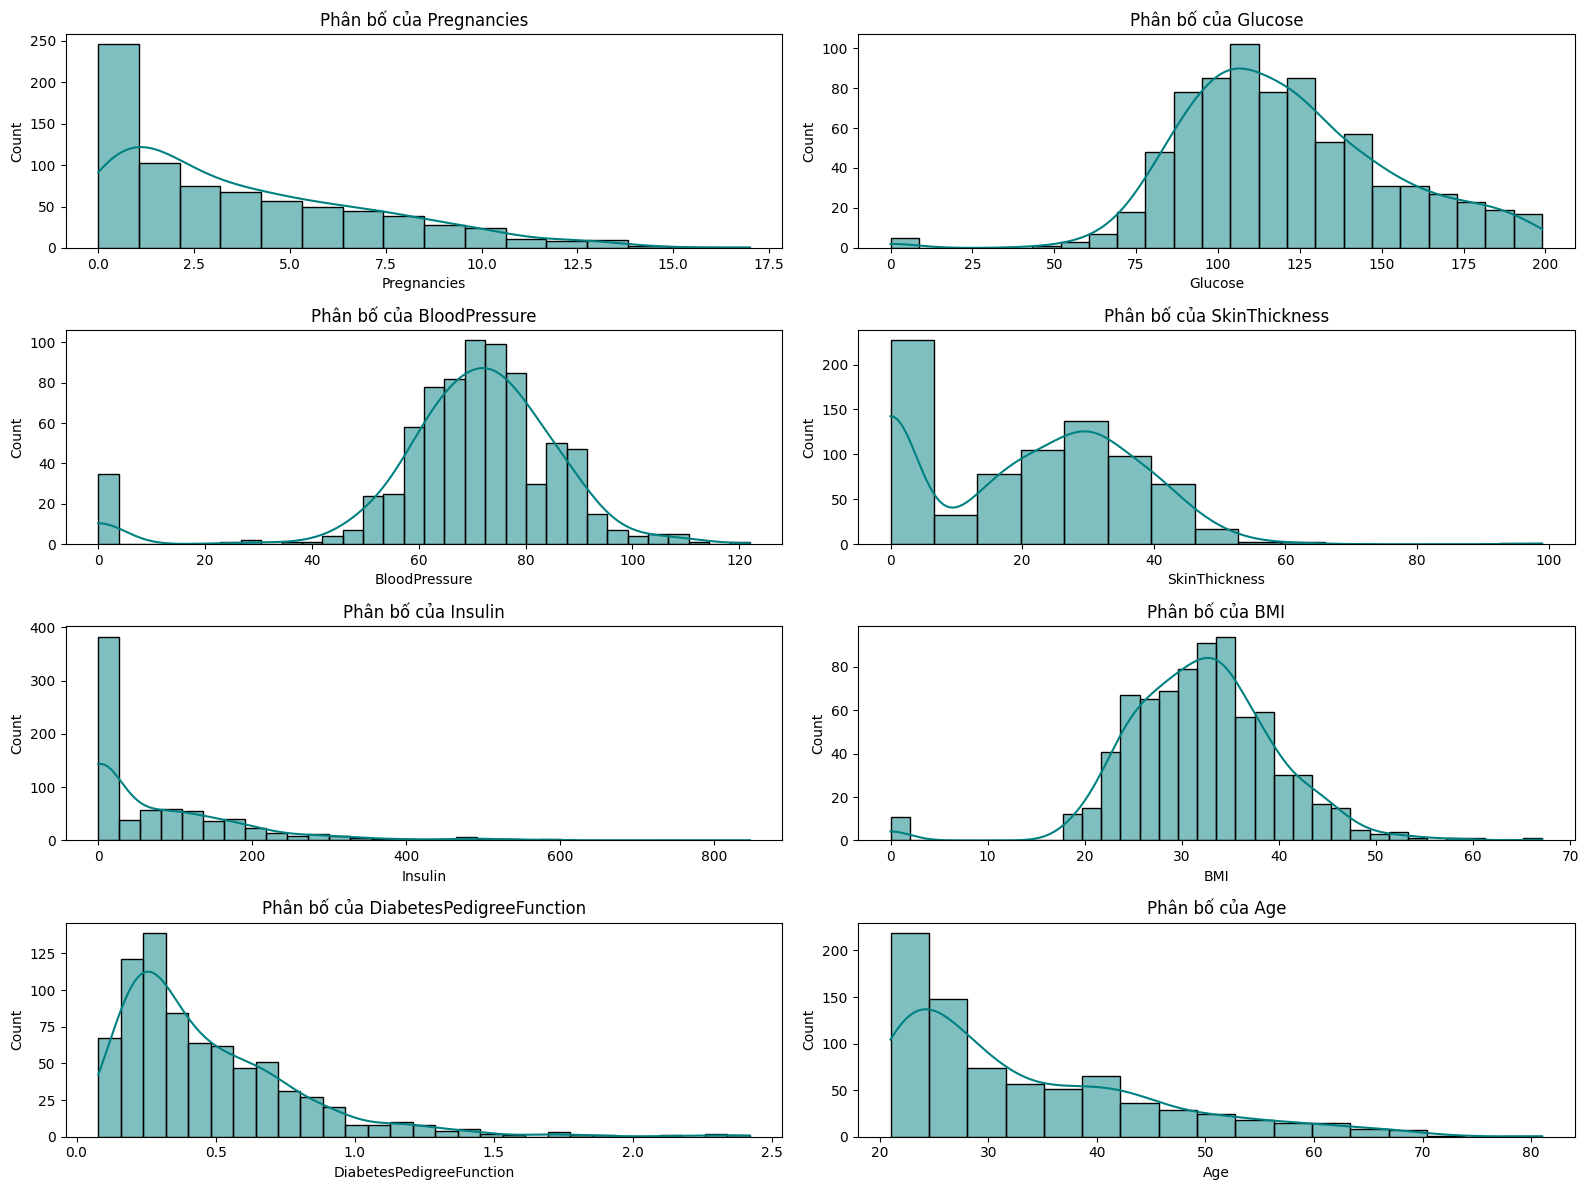

In [7]:
features = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

plt.figure(figsize=(16, 12))
for i, col in enumerate(features, 1):
    plt.subplot(4, 2, i)
    sns.histplot(df[col], kde=True, color='teal')
    plt.title(f'Phân bố của {col}')
plt.tight_layout()
plt.show()

Pregnancies
- Lệch phải mạnh (right-skewed)

Insulin
- Lệch cực mạnh
- Có tail rất dài

Age
- Phần lớn nằm ở 20–40

BMI
- Gần normal distribution

C:\Users\84352\AppData\Local\Temp\ipykernel_10016\1035506182.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Outcome', y=col, data=df, palette='viridis')
C:\Users\84352\AppData\Local\Temp\ipykernel_10016\1035506182.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Outcome', y=col, data=df, palette='viridis')
C:\Users\84352\AppData\Local\Temp\ipykernel_10016\1035506182.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Outcome', y=col, data=df, palette='viridis')
C:\Users\84352\AppData\Local\Temp\ipykernel_10016\1035506182.py:

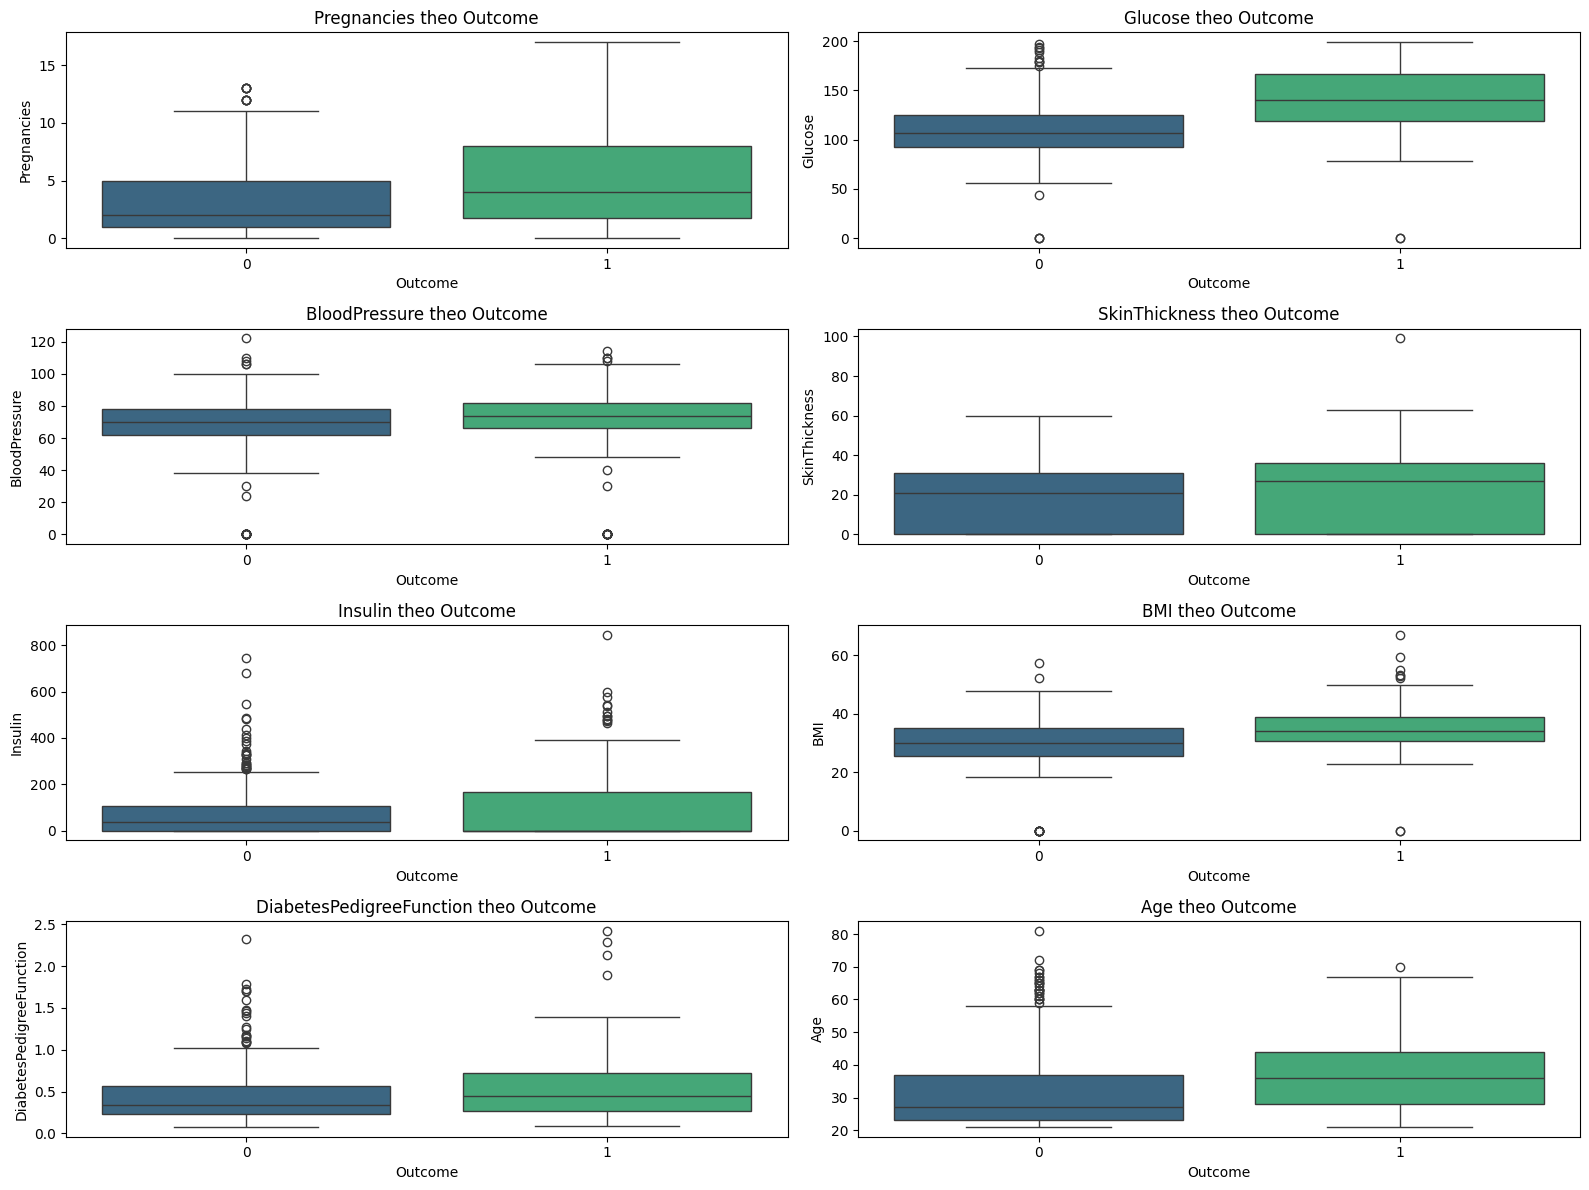

In [8]:
# Boxplot theo Outcome
plt.figure(figsize=(16, 12))
for i, col in enumerate(features, 1):
    plt.subplot(4, 2, i)
    sns.boxplot(x='Outcome', y=col, data=df, palette='viridis')
    plt.title(f'{col} theo Outcome')
plt.tight_layout()
plt.show()

Các biểu đồ này để xem feature nào tách nhóm tốt.

Glucose
- Median của nhóm bệnh cao rõ rệt.
- IQR tách biệt khá rõ.
→ Feature rất mạnh.

BMI
- Nhóm bệnh BMI cao hơn.
- Nhưng overlap lớn.
→ Feature trung bình.

Pregnancies
- Người bị tiểu đường có xu hướng mang thai nhiều lần hơn.
- Nhưng variance cao.

Age

- Nhóm bệnh già hơn.

Insulin
- Rất nhiều outlier.
→ rất nhiều 0 và đây là missing value trá hình.

## 5. Tỷ lệ Outcome (class imbalance)

C:\Users\84352\AppData\Local\Temp\ipykernel_10016\4009031804.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Outcome', data=df, palette='viridis')


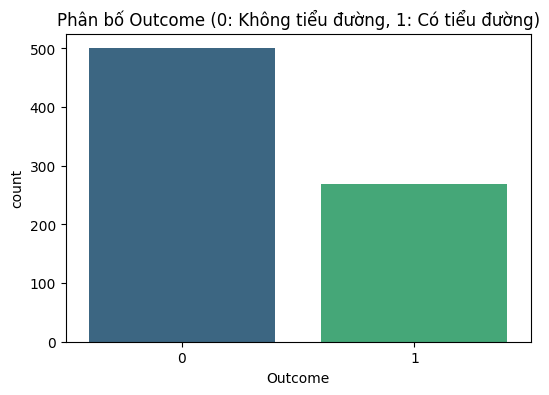

Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64


In [9]:
plt.figure(figsize=(6,4))
sns.countplot(x='Outcome', data=df, palette='viridis')
plt.title('Phân bố Outcome (0: Không tiểu đường, 1: Có tiểu đường)')
plt.show()

print(df['Outcome'].value_counts(normalize=True) * 100)

**Nhận xét**
- Dataset mất cân bằng nhẹ
- ~65% : 35%
→ không quá nghiêm trọng.

## 6. Correlation Heatmap

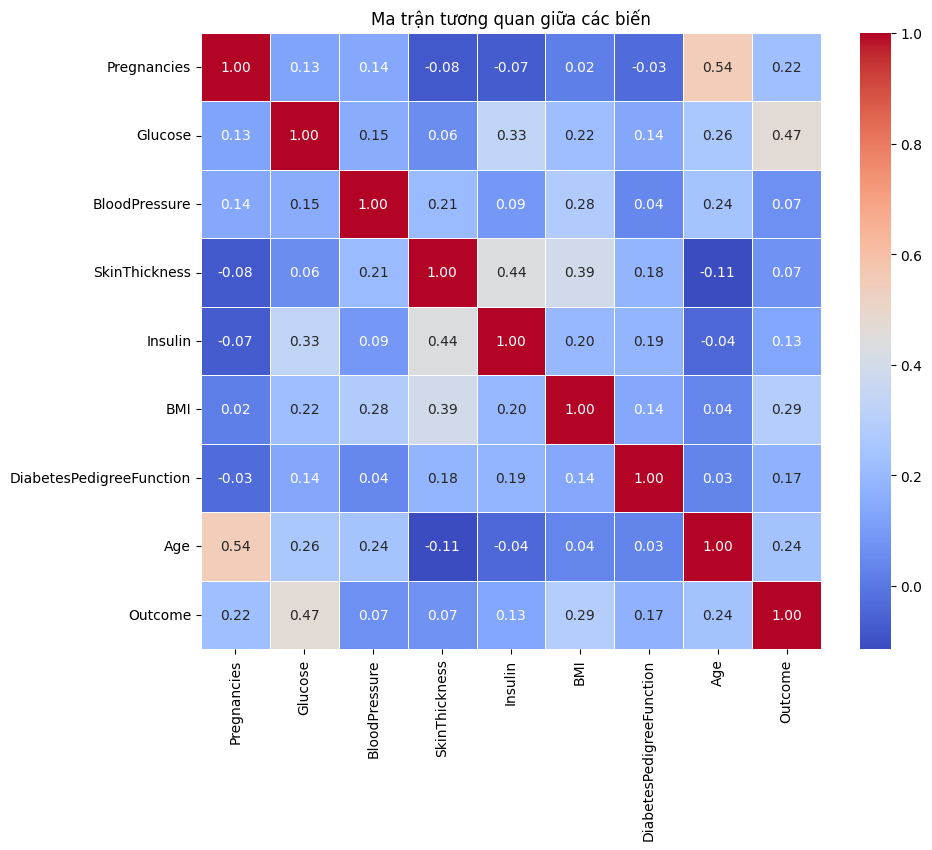

In [10]:
plt.figure(figsize=(10,8))
corr = df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Ma trận tương quan giữa các biến')
plt.show()

Nhận xét

**Glucose**
- Tương quan mạnh nhất với Outcome
- Đây gần như feature chính của model

**BMI**
- Có ảnh hưởng nhưng không quá mạnh

**Age**
- Ảnh hưởng nhẹ

**Insulin**
- Corr thấp 
→ vì dữ liệu bị nhiễu do nhiều giá trị 0

## 7. Pairplot (quan hệ đôi giữa các biến quan trọng)

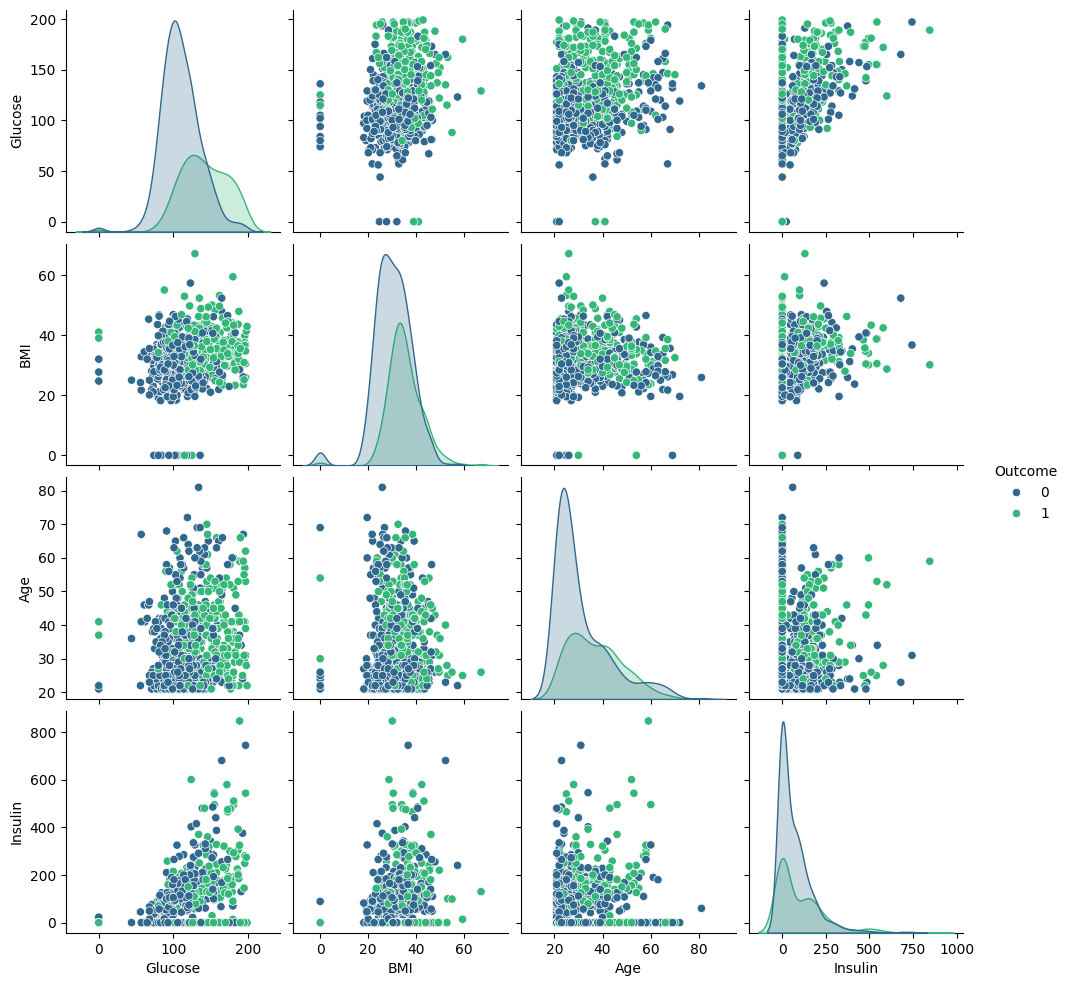

In [11]:
important_cols = ['Glucose', 'BMI', 'Age', 'Insulin', 'Outcome']
sns.pairplot(df[important_cols], hue='Outcome', palette='viridis', diag_kind='kde')
plt.show()

Nhận xét

**Glucose**
- Nhóm Outcome = 1 (bị tiểu đường) tập trung ở vùng Glucose cao.
- Đây là biến tách lớp rõ nhất 
→ feature quan trọng.

**BMI**
- Người có BMI cao có xu hướng nằm ở nhóm Outcome = 1 nhiều hơn.
- Nhưng vẫn overlap lớn.

**Age**
- Tuổi cao thì khả năng mắc bệnh tăng.
- Nhưng phân bố vẫn chồng lấn nhiều.

**Insulin**
- Phân tán rất mạnh.
- Có nhiều điểm Insulin = 0 
→ bất thường (sinh lý gần như không thể).

## 8. Kết luận & Insights từ EDA

**Quan sát chính:**
1. Glucose là biến quan trọng nhất (tương quan cao nhất với Outcome ~0.47)
2. BMI, Age, DiabetesPedigreeFunction cũng có ảnh hưởng rõ rệt
3. Nhiều giá trị 0 ở Glucose, BMI, Insulin → cần xử lý missing values (thay bằng median)
4. Có outlier ở Insulin, DiabetesPedigreeFunction, BMI → có thể cần xử lý (clip hoặc log transform)
5. Class imbalance ~65% - 35% → nên dùng class_weight='balanced' hoặc SMOTE
6. Không có missing value NaN thật, chỉ có giá trị 0 không hợp lý

**Hành động preprocessing đề xuất:**
- Thay 0 → NaN ở Glucose, BloodPressure, SkinThickness, Insulin, BMI
- Impute bằng median
- Scale dữ liệu (StandardScaler)
- Xử lý outlier nếu cần (ví dụ clip tại percentile 99)
- Giữ nguyên Pregnancies và Age (có 0 là hợp lý)